# FPS Downsampling Experiment: Face Exposure Time Variability

This notebook analyzes how downsampling video frame rates affects the estimation of face exposure time across multiple participants.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['grid.alpha'] = 0.3

# Configuration
DATA_DIR = Path(r"C:\Users\parsadlr\Documents\Parsa\Projects\fps_experiment\data")
ORIGINAL_FPS = 25
CSV_FILENAME = "faces_combined.csv"
MAX_SUBRECORDINGS = 50  # Maximum number of subrecordings to create (to avoid explosion for high factors)


## Define Downsampling Rates

We'll test multiple downsampling rates (all treated as downsampling factors):
- 12, 6, 3, 1 fps
- 1 frame every 2s, 4s, 8s, 15s, 30s, 60s, 120s


In [2]:
def get_downsampling_configs():
    """
    Returns a list of downsampling configurations.
    All are treated uniformly as downsampling factors.
    If the downsample factor exceeds MAX_SUBRECORDINGS, we cap it at that maximum.
    
    Each config is a dict with: name, target_fps, downsample_factor, n_subrecordings, mod_divisor
    """
    configs = []
    
    # FPS-based downsampling: 12, 6, 3, 1 fps
    fps_targets = [12, 6, 3, 1]
    for target_fps in fps_targets:
        downsample_factor = ORIGINAL_FPS / target_fps
        # Number of subrecordings = rounded downsample factor, capped at MAX_SUBRECORDINGS
        n_subrecordings = min(int(np.round(downsample_factor)), MAX_SUBRECORDINGS)
        configs.append({
            'name': f'{target_fps} fps',
            'target_fps': target_fps,
            'downsample_factor': downsample_factor,
            'n_subrecordings': n_subrecordings,
            'mod_divisor': int(np.round(downsample_factor))  # Original factor for mod operation
        })
    
    # Time-based downsampling: 1 frame every N seconds
    time_intervals = [2, 4, 8, 15, 30, 60, 120]  # seconds
    for interval_sec in time_intervals:
        # Calculate frames per interval (this is the downsample factor)
        downsample_factor = interval_sec * ORIGINAL_FPS
        # Number of subrecordings = downsample factor, capped at MAX_SUBRECORDINGS
        n_subrecordings = min(int(downsample_factor), MAX_SUBRECORDINGS)
        target_fps = 1.0 / interval_sec  # effective fps
        configs.append({
            'name': f'1 frame/{interval_sec}s',
            'target_fps': target_fps,
            'downsample_factor': downsample_factor,
            'n_subrecordings': n_subrecordings,
            'mod_divisor': int(downsample_factor)  # Original factor for mod operation
        })
    
    return configs

downsample_configs = get_downsampling_configs()
print(f"Total downsampling configurations: {len(downsample_configs)}")
for i, config in enumerate(downsample_configs):
    print(f"{i+1}. {config['name']}: factor={config['downsample_factor']:.2f}, {config['n_subrecordings']} subrecordings")


Total downsampling configurations: 11
1. 12 fps: factor=2.08, 2 subrecordings
2. 6 fps: factor=4.17, 4 subrecordings
3. 3 fps: factor=8.33, 8 subrecordings
4. 1 fps: factor=25.00, 25 subrecordings
5. 1 frame/2s: factor=50.00, 50 subrecordings
6. 1 frame/4s: factor=100.00, 50 subrecordings
7. 1 frame/8s: factor=200.00, 50 subrecordings
8. 1 frame/15s: factor=375.00, 50 subrecordings
9. 1 frame/30s: factor=750.00, 50 subrecordings
10. 1 frame/60s: factor=1500.00, 50 subrecordings
11. 1 frame/120s: factor=3000.00, 50 subrecordings


## Load Data and Calculate Exposure Times

For each participant, we'll:
1. Load the faces_combined CSV file
2. For each downsampling configuration, create multiple subrecordings
3. Calculate exposure time for each subrecording (for all faces and attended faces)
4. Compute variance across subrecordings


In [3]:
def calculate_exposure_time(df, target_fps, attended_only=False):
    """
    Calculate exposure time from a dataframe.
    
    Important: Each (session_name, frame_number) combination is counted separately.
    If the same frame_number appears in multiple sessions, each occurrence contributes
    to the exposure time.
    
    Also important: At different downsampling rates, each frame represents different
    temporal duration. For example:
    - At 25 fps: each frame = 1/25 seconds
    - At 1 fps: each frame = 1 second
    - At 1 frame/2s: each frame = 2 seconds
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe with columns: session_name, frame_number, attended
    target_fps : float
        Target FPS for calculating time (frame duration = 1/target_fps)
    attended_only : bool
        If True, only count frames with at least one attended face
        
    Returns:
    --------
    exposure_time : float
        Exposure time in seconds
    """
    if attended_only:
        # Filter to only rows where attended == 1
        df_filtered = df[df['attended'] == 1].copy()
    else:
        df_filtered = df.copy()
    
    # Count unique combinations of (session_name, frame_number)
    # This correctly handles cases where the same frame_number appears in multiple sessions
    # Each (session, frame) combination is a distinct temporal moment
    unique_frames = df_filtered[['session_name', 'frame_number']].drop_duplicates()
    n_frames = len(unique_frames)
    
    # Exposure time = number of frames * frame duration at this sampling rate
    # At target_fps, each frame represents (1/target_fps) seconds
    frame_duration = 1.0 / target_fps
    exposure_time = n_frames * frame_duration
    
    return exposure_time


def downsample_frames(frame_numbers, config):
    """
    Create subrecordings by downsampling frames.
    
    If the original downsample factor is N, but we're capped at n_subrecordings,
    we uniformly sample n_subrecordings offsets from the range [0, N-1].
    
    For example, if mod_divisor=3000 and n_subrecordings=50, we use offsets
    [0, 60, 120, 180, ..., 2940] (uniformly spaced).
    
    Parameters:
    -----------
    frame_numbers : array-like
        Original frame numbers
    config : dict
        Downsampling configuration with 'mod_divisor' and 'n_subrecordings'
        
    Returns:
    --------
    subrecordings : list of arrays
        List of frame number arrays, one per subrecording
    """
    mod_divisor = config['mod_divisor']
    n_sub = config['n_subrecordings']
    
    # If n_subrecordings equals mod_divisor, use all offsets 0 to mod_divisor-1
    # Otherwise, uniformly sample n_subrecordings offsets from [0, mod_divisor-1]
    if n_sub >= mod_divisor:
        offsets = list(range(mod_divisor))
    else:
        # Uniformly sample n_sub offsets
        step = mod_divisor / n_sub
        offsets = [int(i * step) for i in range(n_sub)]
    
    subrecordings = []
    for offset in offsets:
        # Take frames where (frame % mod_divisor) == offset
        # This creates subrecordings with uniformly sampled offsets
        frames_sub = [f for f in frame_numbers if (f % mod_divisor) == offset]
        subrecordings.append(np.array(frames_sub))
    
    return subrecordings


def process_participant(participant_dir, configs, attended_only=False):
    """
    Process a single participant and calculate exposure time variance for each config.
    
    Parameters:
    -----------
    participant_dir : Path
        Directory containing the participant's data
    configs : list
        List of downsampling configurations
    attended_only : bool
        If True, only count attended faces
        
    Returns:
    --------
    results : dict
        Dictionary with variance for each config
    """
    csv_path = participant_dir / CSV_FILENAME
    
    if not csv_path.exists():
        print(f"Warning: {csv_path} not found, skipping...")
        return None
    
    # Load CSV file
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        print(f"Error loading {csv_path}: {e}")
        return None
    
    # Verify required columns exist
    required_cols = ['face_id', 'session_name', 'frame_number', 'attended']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Warning: Missing columns in {csv_path}: {missing_cols}")
        return None
    
    results = {}
    
    # Get all unique frame numbers across all sessions
    # Note: The same frame_number can appear in multiple sessions,
    # and we'll handle that correctly when counting unique (session, frame) pairs
    all_frames = df['frame_number'].unique()
    
    for config in configs:
        # Create subrecordings for this config
        # Each subrecording contains a subset of frame numbers based on downsampling
        subrecordings_frames = downsample_frames(all_frames, config)
        
        if len(subrecordings_frames) == 0:
            continue
        
        # Calculate exposure time for each subrecording
        exposure_times = []
        
        for subrec_frames in subrecordings_frames:
            if len(subrec_frames) == 0:
                continue
            
            # Filter dataframe to this subrecording's frames
            # This includes ALL sessions that have these frame numbers
            # For example, if frame 0 appears in both session A and session B,
            # both will be included in df_subrec
            df_subrec = df[df['frame_number'].isin(subrec_frames)]
            
            # Calculate exposure time
            # This correctly counts unique (session_name, frame_number) pairs
            # and multiplies by the frame duration at this sampling rate
            exp_time = calculate_exposure_time(
                df_subrec, 
                config['target_fps'], 
                attended_only=attended_only
            )
            exposure_times.append(exp_time)
        
        if len(exposure_times) > 0:
            # Calculate variance across subrecordings
            variance = np.var(exposure_times)
            mean_exp_time = np.mean(exposure_times)
            std_exp_time = np.std(exposure_times)
            
            results[config['name']] = {
                'variance': variance,
                'mean': mean_exp_time,
                'std': std_exp_time,
                'n_subrecordings': len(exposure_times),
                'exposure_times': exposure_times
            }
    
    return results


# Test with a single participant first
print("Testing with first participant...")
participant_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]

if len(participant_dirs) == 0:
    print(f"No participant directories found in {DATA_DIR}")
else:
    print(f"Found {len(participant_dirs)} participant directories")
    test_dir = participant_dirs[0]
    print(f"\nTesting with: {test_dir.name}")
    test_results = process_participant(test_dir, downsample_configs, attended_only=False)
    if test_results:
        print(f"Successfully processed. Got results for {len(test_results)} configurations.")
        print("\nSample results (first 3 configs):")
        for i, (name, data) in enumerate(list(test_results.items())[:3]):
            print(f"  {name}: variance={data['variance']:.2f}, mean={data['mean']:.2f}s")


Testing with first participant...
Found 5 participant directories

Testing with: pilot-1
Successfully processed. Got results for 11 configurations.

Sample results (first 3 configs):
  12 fps: variance=5.64, mean=3458.38s
  6 fps: variance=13.27, mean=3458.38s
  3 fps: variance=33.18, mean=3458.38s


## Process All Participants

Now we'll process all participants and collect results for both all faces and attended faces only.


In [4]:
# Process all participants
all_participants_results = {}
all_participants_attended_results = {}

print("Processing all participants...\n")
for participant_dir in participant_dirs:
    participant_name = participant_dir.name
    print(f"Processing {participant_name}...")
    
    # All faces
    results_all = process_participant(participant_dir, downsample_configs, attended_only=False)
    if results_all:
        all_participants_results[participant_name] = results_all
    
    # Attended faces only
    results_attended = process_participant(participant_dir, downsample_configs, attended_only=True)
    if results_attended:
        all_participants_attended_results[participant_name] = results_attended

print(f"\n\nSuccessfully processed {len(all_participants_results)} participants")
print(f"  - All faces: {len(all_participants_results)} participants")
print(f"  - Attended only: {len(all_participants_attended_results)} participants")


Processing all participants...

Processing pilot-1...
Processing pilot-2...
Processing pilot-3...
Processing pilot-4...
Processing pilot-5...


Successfully processed 5 participants
  - All faces: 5 participants
  - Attended only: 5 participants


## Aggregate Results and Create Plots

We'll create plots showing variance of exposure time estimates vs downsampling rate for each participant.


In [5]:
def aggregate_results(participants_results, configs):
    """
    Aggregate results across all participants.
    
    Returns a dataframe with columns: participant, config_name, variance, mean, std
    """
    rows = []
    for participant_name, results in participants_results.items():
        for config_name, data in results.items():
            rows.append({
                'participant': participant_name,
                'config_name': config_name,
                'variance': data['variance'],
                'mean': data['mean'],
                'std': data['std'],
                'n_subrecordings': data['n_subrecordings']
            })
    
    df = pd.DataFrame(rows)
    
    # Add metadata from configs
    config_map = {c['name']: c for c in configs}
    df['target_fps'] = df['config_name'].map(lambda x: config_map[x]['target_fps'])
    df['downsample_factor'] = df['config_name'].map(lambda x: config_map[x]['downsample_factor'])
    
    # Sort by downsample_factor for better visualization
    df = df.sort_values('downsample_factor')
    
    return df


# Create aggregated dataframes
df_all = aggregate_results(all_participants_results, downsample_configs)
df_attended = aggregate_results(all_participants_attended_results, downsample_configs)

print("All faces - Summary:")
print(df_all.groupby('config_name')['std'].agg(['mean', 'std', 'count']))
print("\n\nAttended faces - Summary:")
print(df_attended.groupby('config_name')['std'].agg(['mean', 'std', 'count']))


All faces - Summary:
                    mean        std  count
config_name                               
1 fps          10.733093   2.873622      5
1 frame/120s  299.714495  79.330147      5
1 frame/15s    85.171426  26.458084      5
1 frame/2s     17.134944   5.535244      5
1 frame/30s   129.777617  39.629693      5
1 frame/4s     34.252473   7.750050      5
1 frame/60s   192.068206  55.395444      5
1 frame/8s     61.941364  22.911053      5
12 fps          1.908333   1.013109      5
3 fps           5.536314   3.120885      5
6 fps           3.163176   1.972757      5


Attended faces - Summary:
                    mean        std  count
config_name                               
1 fps           9.436009   4.781692      5
1 frame/120s  153.075197  67.284250      5
1 frame/15s    48.292604  24.006416      5
1 frame/2s     14.870139   8.173806      5
1 frame/30s    66.321562  30.816928      5
1 frame/4s     20.736280   9.262891      5
1 frame/60s    97.767208  42.777170      5
1 fra

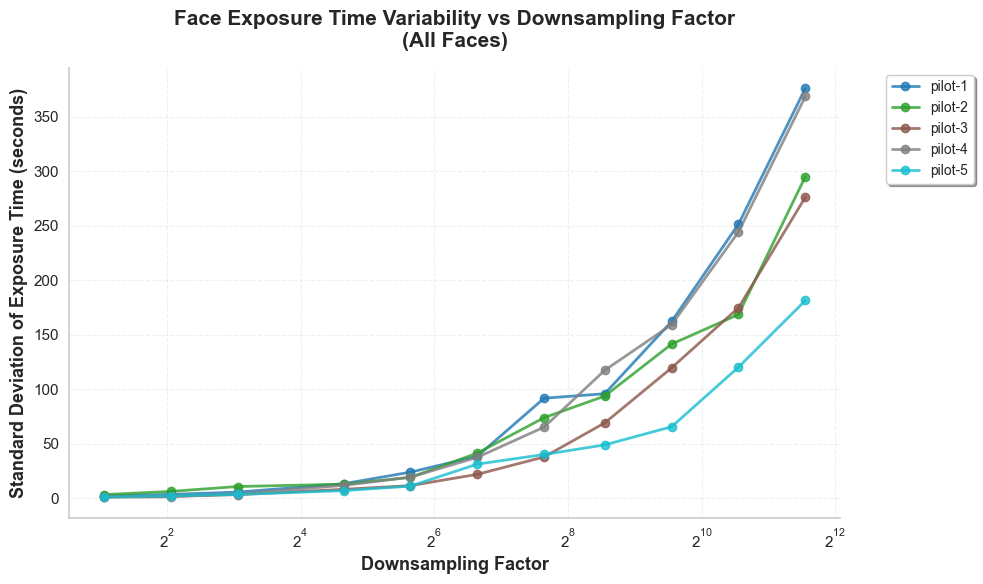

In [6]:
# Plot 1: Standard Deviation vs Downsampling Factor for All Participants (All Faces)
fig, ax = plt.subplots(figsize=(10, 6))

# Get unique participants, sort them, and assign colors
participants = sorted(df_all['participant'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(participants)))

for i, participant in enumerate(participants):
    participant_data = df_all[df_all['participant'] == participant].sort_values('downsample_factor')
    ax.plot(participant_data['downsample_factor'], participant_data['std'], 
            marker='o', label=participant, alpha=0.8, linewidth=2, 
            markersize=6, color=colors[i])

ax.set_xlabel('Downsampling Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Standard Deviation of Exposure Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Face Exposure Time Variability vs Downsampling Factor\n(All Faces)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


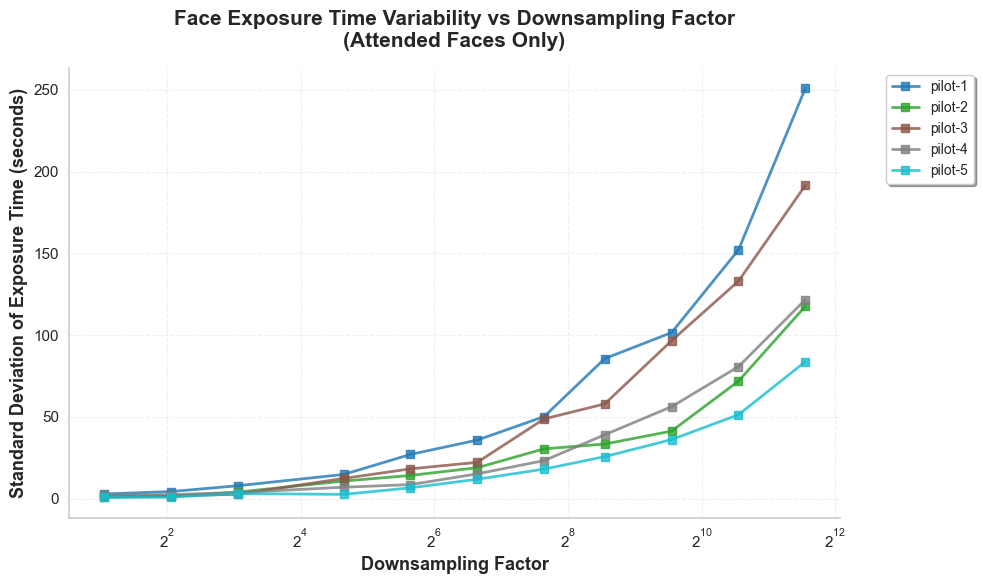

In [7]:
# Plot 2: Standard Deviation vs Downsampling Factor for All Participants (Attended Faces Only)
fig, ax = plt.subplots(figsize=(10, 6))

# Get unique participants, sort them, and assign colors
participants = sorted(df_attended['participant'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(participants)))

for i, participant in enumerate(participants):
    participant_data = df_attended[df_attended['participant'] == participant].sort_values('downsample_factor')
    ax.plot(participant_data['downsample_factor'], participant_data['std'], 
            marker='s', label=participant, alpha=0.8, linewidth=2, 
            markersize=6, color=colors[i])

ax.set_xlabel('Downsampling Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Standard Deviation of Exposure Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Face Exposure Time Variability vs Downsampling Factor\n(Attended Faces Only)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xscale('log', base=2)
# ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


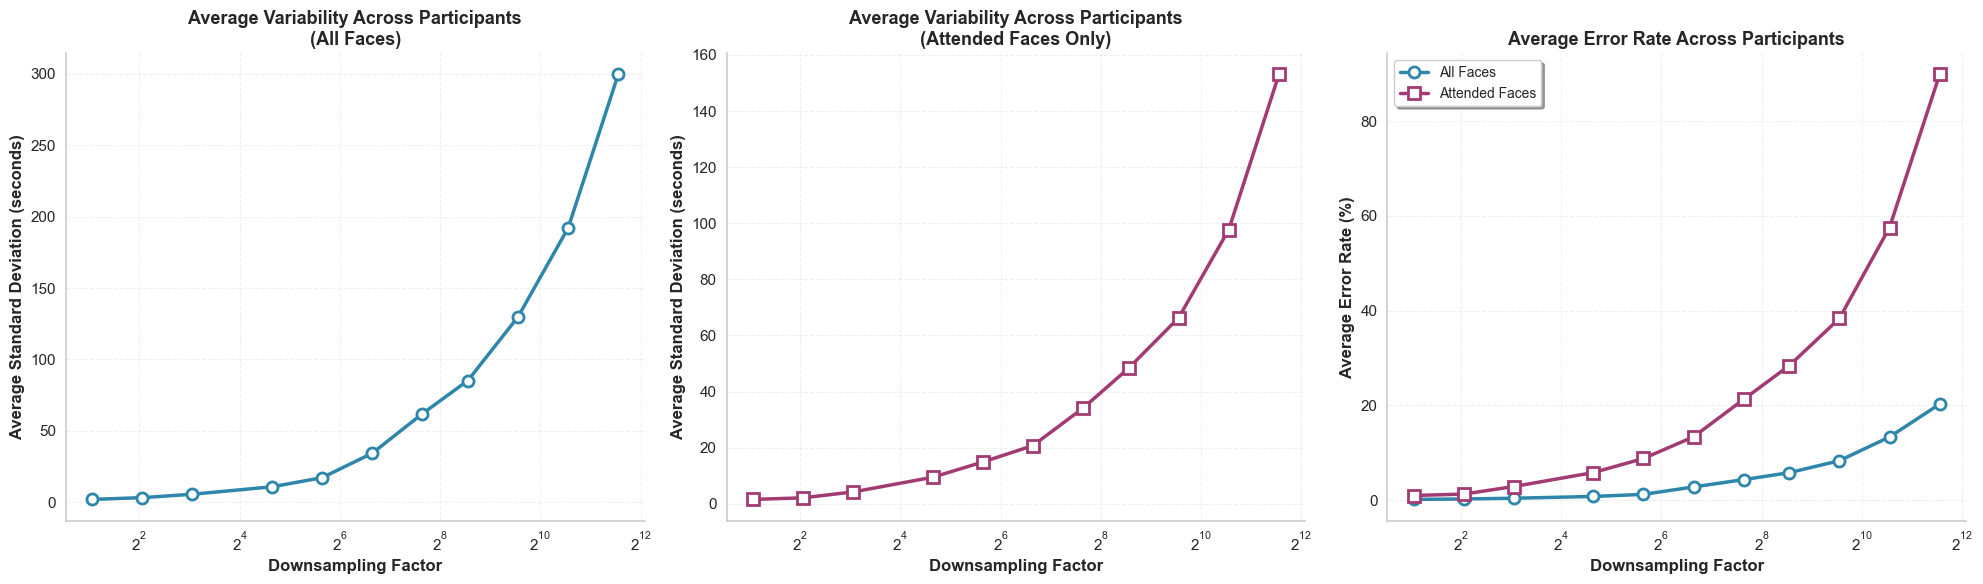

In [18]:
# Plot 3: Average Standard Deviation and Error Rate (CV) Across Participants
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# All faces
avg_std_all = df_all.groupby('config_name')['std'].mean().reset_index()
avg_std_all = avg_std_all.merge(
    df_all[['config_name', 'downsample_factor']].drop_duplicates(), 
    on='config_name'
).sort_values('downsample_factor')

ax1.plot(avg_std_all['downsample_factor'], avg_std_all['std'], 
         marker='o', linewidth=2.5, markersize=8, color='#2E86AB', markerfacecolor='white', 
         markeredgewidth=2)
ax1.set_xlabel('Downsampling Factor', fontsize=12, fontweight='bold')
ax1.set_ylabel('Average Standard Deviation (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Average Variability Across Participants\n(All Faces)', fontsize=13, fontweight='bold')
ax1.set_xscale('log', base=2)
# ax1.set_yscale('log')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Attended faces
avg_std_attended = df_attended.groupby('config_name')['std'].mean().reset_index()
avg_std_attended = avg_std_attended.merge(
    df_attended[['config_name', 'downsample_factor']].drop_duplicates(), 
    on='config_name'
).sort_values('downsample_factor')

ax2.plot(avg_std_attended['downsample_factor'], avg_std_attended['std'], 
         marker='s', linewidth=2.5, markersize=8, color='#A23B72', markerfacecolor='white', 
         markeredgewidth=2)
ax2.set_xlabel('Downsampling Factor', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Standard Deviation (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Average Variability Across Participants\n(Attended Faces Only)', fontsize=13, fontweight='bold')
ax2.set_xscale('log', base=2)
# ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Calculate CV (std/mean) for each participant and config, then average across participants
# First, ensure CV is calculated
df_all['cv'] = df_all['std'] / df_all['mean']
df_attended['cv'] = df_attended['std'] / df_attended['mean']

# Average CV across participants for all faces (convert to %)
avg_cv_all = df_all.groupby('config_name')['cv'].mean().reset_index()
avg_cv_all = avg_cv_all.merge(
    df_all[['config_name', 'downsample_factor']].drop_duplicates(), 
    on='config_name'
).sort_values('downsample_factor')
avg_cv_all['cv_pct'] = avg_cv_all['cv'] * 100

ax3.plot(avg_cv_all['downsample_factor'], avg_cv_all['cv_pct'], 
         marker='o', linewidth=2.5, markersize=8, color='#2E86AB', markerfacecolor='white', 
         markeredgewidth=2, label='All Faces')
ax3.set_xlabel('Downsampling Factor', fontsize=12, fontweight='bold')
ax3.set_ylabel('Average Error Rate (%)', fontsize=12, fontweight='bold')
ax3.set_title('Average Error Rate Across Participants', fontsize=13, fontweight='bold')
ax3.set_xscale('log', base=2)
# ax3.set_yscale('log')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Also add attended faces to the same plot (convert to %)
avg_cv_attended = df_attended.groupby('config_name')['cv'].mean().reset_index()
avg_cv_attended = avg_cv_attended.merge(
    df_attended[['config_name', 'downsample_factor']].drop_duplicates(), 
    on='config_name'
).sort_values('downsample_factor')
avg_cv_attended['cv_pct'] = avg_cv_attended['cv'] * 100

ax3.plot(avg_cv_attended['downsample_factor'], avg_cv_attended['cv_pct'], 
         marker='s', linewidth=2.5, markersize=8, color='#A23B72', markerfacecolor='white', 
         markeredgewidth=2, label='Attended Faces')
ax3.legend(frameon=True, fancybox=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.show()


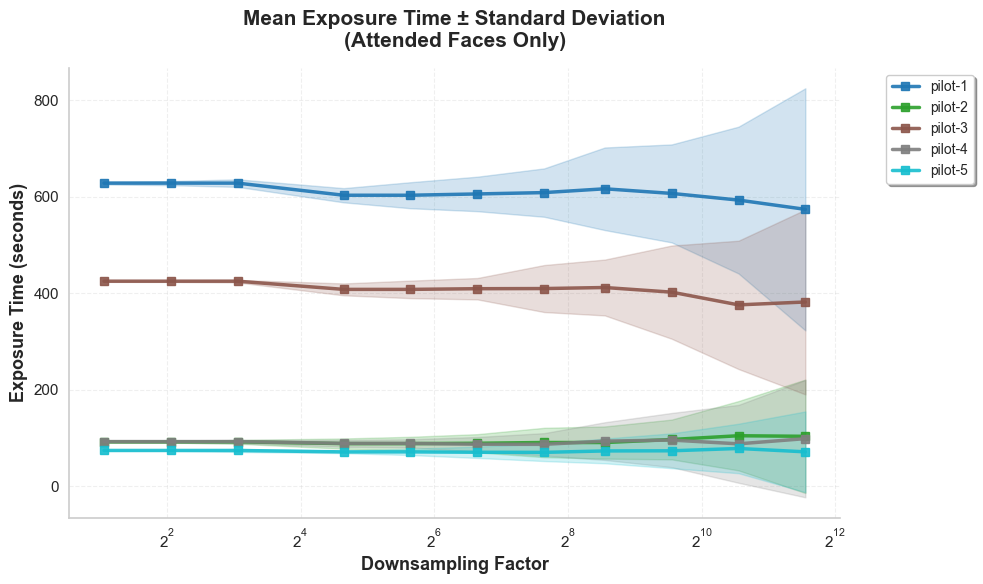

In [9]:
# Plot 4b: Mean ± Std for Each Participant (Attended Faces Only)
fig, ax = plt.subplots(figsize=(10, 6))

participants = sorted(df_attended['participant'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(participants)))

for i, participant in enumerate(participants):
    participant_data = df_attended[df_attended['participant'] == participant].sort_values('downsample_factor')
    
    # Plot mean line
    ax.plot(participant_data['downsample_factor'], participant_data['mean'], 
            marker='s', label=participant, alpha=0.9, linewidth=2.5, 
            markersize=6, color=colors[i], zorder=3)
    
    # Plot shaded area for std
    ax.fill_between(participant_data['downsample_factor'],
                    participant_data['mean'] - participant_data['std'],
                    participant_data['mean'] + participant_data['std'],
                    alpha=0.2, color=colors[i], zorder=1)

ax.set_xlabel('Downsampling Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Exposure Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Mean Exposure Time ± Standard Deviation\n(Attended Faces Only)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xscale('log', base=2)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


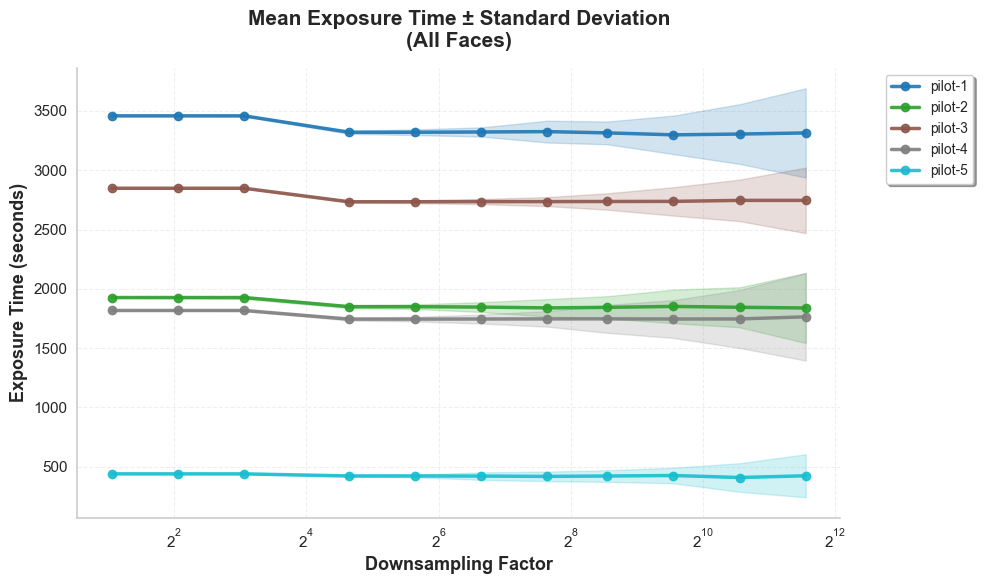

In [10]:
# Plot 4: Mean ± Std for Each Participant (All Faces)
df_all['cv'] = df_all['std'] / df_all['mean']
df_attended['cv'] = df_attended['std'] / df_attended['mean']

# Plot 4a: Mean ± Std for Each Participant (All Faces)
fig, ax = plt.subplots(figsize=(10, 6))

participants = sorted(df_all['participant'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(participants)))

for i, participant in enumerate(participants):
    participant_data = df_all[df_all['participant'] == participant].sort_values('downsample_factor')
    
    # Plot mean line
    ax.plot(participant_data['downsample_factor'], participant_data['mean'], 
            marker='o', label=participant, alpha=0.9, linewidth=2.5, 
            markersize=6, color=colors[i], zorder=3)
    
    # Plot shaded area for std
    ax.fill_between(participant_data['downsample_factor'],
                    participant_data['mean'] - participant_data['std'],
                    participant_data['mean'] + participant_data['std'],
                    alpha=0.2, color=colors[i], zorder=1)

ax.set_xlabel('Downsampling Factor', fontsize=13, fontweight='bold')
ax.set_ylabel('Exposure Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Mean Exposure Time ± Standard Deviation\n(All Faces)', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xscale('log', base=2)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Summary Statistics

Let's create a summary table showing how variance changes with downsampling.


In [11]:
# Create summary statistics
summary_all = df_all.groupby('config_name').agg({
    'variance': ['mean', 'std', 'min', 'max'],
    'mean': 'mean',
    'std': 'mean',
    'cv': 'mean'
}).round(4)

summary_attended = df_attended.groupby('config_name').agg({
    'variance': ['mean', 'std', 'min', 'max'],
    'mean': 'mean',
    'std': 'mean',
    'cv': 'mean'
}).round(4)

# Add target_fps column
config_map = {c['name']: c for c in downsample_configs}
summary_all['target_fps'] = [config_map[name]['target_fps'] for name in summary_all.index]
summary_attended['target_fps'] = [config_map[name]['target_fps'] for name in summary_attended.index]

# Sort by target_fps
summary_all = summary_all.sort_values('target_fps')
summary_attended = summary_attended.sort_values('target_fps')

print("=" * 80)
print("SUMMARY: All Faces")
print("=" * 80)
print(summary_all)
print("\n" + "=" * 80)
print("SUMMARY: Attended Faces Only")
print("=" * 80)
print(summary_attended)


SUMMARY: All Faces
                variance                                            mean  \
                    mean         std         min          max       mean   
config_name                                                                
1 frame/120s  94863.3961  45043.2746  32974.2607  141632.6400  2017.2147   
1 frame/60s   39345.1200  21245.2040  14499.3600   63336.9600  2010.0000   
1 frame/30s   18098.6400   9075.8007   4320.0000   26366.7600  2011.6800   
1 frame/15s    7814.1960   4399.9592   2408.7600   13825.4400  2012.6400   
1 frame/8s     4256.6656   2912.7369   1445.9904    8449.1264  2012.9920   
1 frame/4s     1221.2826    489.6220    486.4064    1723.0336  2014.0960   
1 frame/2s      318.1174    190.0293    126.1904     579.1184  2014.0880   
1 fps           121.8054     59.0670     49.9104     179.5584  2014.0880   
3 fps            38.4427     45.3359     11.5955     118.0538  2098.0083   
6 fps            13.1191     15.9862      2.0052      40.6858  2098.0

## Export Results

Optionally export the results to CSV files for further analysis.


In [12]:
# # Export to CSV
# output_dir = DATA_DIR.parent / "fps_experiment_results"
# output_dir.mkdir(exist_ok=True)

# df_all.to_csv(output_dir / "results_all_faces.csv", index=False)
# df_attended.to_csv(output_dir / "results_attended_faces.csv", index=False)
# summary_all.to_csv(output_dir / "summary_all_faces.csv")
# summary_attended.to_csv(output_dir / "summary_attended_faces.csv")

# print(f"Results exported to: {output_dir}")
# print(f"  - results_all_faces.csv")
# print(f"  - results_attended_faces.csv")
# print(f"  - summary_all_faces.csv")
# print(f"  - summary_attended_faces.csv")
